# Wirtualny Sommelier - Klasyfikacja Jakości Wina Czerwonego

Projekt realizuje pełny potok uczenia maszynowego mający na celu automatyczną klasyfikację jakości czerwonego wina na podstawie jego fizykochemicznych parametrów. Zbiór danych pochodzi z bazy `winequality-red.csv`.

## Cel projektu:
Klasyfikacja binarna jakości wina:
- **Klasa 1 (Dobre / Premium):** Ocena jakości >= 6
- **Klasa 0 (Przeciętne / Słabe):** Ocena jakości < 6

## Plan projektu:
1. **Wczytanie i Podział Danych:** Podział na zbiory: treningowy (70%), walidacyjny (15%) i testowy (15%) ze stratyfikacją.
2. **Etap 1 - Preprocessing i Inżynieria Cech:** Imputacja braków danych, transformacja logarytmiczna, standaryzacja, redukcja współliniowości (VIF), usuwanie obserwacji wpływowych (odległość Cooka).
3. **Etap 2 - Optymalizacja i Dobór Modelu:** Porównanie wielu modeli w 5-krotnej walidacji krzyżowej i Grid Search dla najlepszego modelu.
4. **Etap 3 - Ewaluacja i Wizualizacja:** Ostateczna ocena na zbiorze testowym oraz wykresy (Confusion Matrix, ROC, Learning Curves).
5. **Etap 4 - Selekcja Cech, Model Lekki i Eksport:** Wybór topowych cech, trening modelu lekkiego i eksport do pliku `.pkl`.

## Krok 1: Instalacja i przygotowanie środowiska

Załadujemy wszystkie niezbędne biblioteki oraz zablokujemy wyświetlanie ostrzeżeń.

In [13]:
# Importy podstawowych bibliotek
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')

# Biblioteki Scikit-Learn i Statsmodels
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Konfiguracja wykresów
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('Środowisko przygotowane pomyślnie.')

Środowisko przygotowane pomyślnie.


## Krok 2: Wczytanie i podział danych

Zaimplementujemy funkcję wczytującą dane z pliku CSV, zamieniającą błędne wartości `?` na `NaN`, dokonującą rebinaryzacji oraz dzielącą dane.

In [14]:
def load_and_split_wine_data(file_path):
    """
    Wczytuje zbiór danych o winie, przeprowadza czyszczenie braków (zamiana '?' na NaN),
    wykonuje rebinaryzację zmiennej docelowej 'quality' (1 dla >= 6, 0 dla < 6)
    oraz dokonuje stratyfikowanego podziału na zbiór treningowy (70%), walidacyjny (15%) i testowy (15%).
    """
    df = pd.read_csv(file_path)

    # Zamiana znaków zapytania na NaN i konwersja na typy numeryczne
    df.replace('?', np.nan, inplace=True)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Rebinaryzacja zmiennej docelowej quality: 1 (Dobre/Premium >= 6), 0 (Przeciętne/Słabe < 6)
    df['quality'] = (df['quality'] >= 6).astype(int)

    X = df.drop('quality', axis=1)
    y = df['quality']

    # Pierwszy podział: 70% trening / 30% tymczasowy
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )

    # Drugi podział: 50% z 30% na walidacyjny (15%) i 50% na testowy (15%)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

# Wczytanie danych z katalogu data
data_path = os.path.join('data', 'winequality-red.csv')
X_train, X_val, X_test, y_train, y_val, y_test = load_and_split_wine_data(data_path)

print(f'Rozmiary zbiorów: Train({len(X_train)}), Val({len(X_val)}), Test({len(X_test)})')
print('\nRozkład klas w zbiorze treningowym:')
print(y_train.value_counts(normalize=True).round(3))

Rozmiary zbiorów: Train(1119), Val(240), Test(240)

Rozkład klas w zbiorze treningowym:
quality
1    0.534
0    0.466
Name: proportion, dtype: float64


Wizualizujemy rozkład jakości wina (zmienna docelowa).

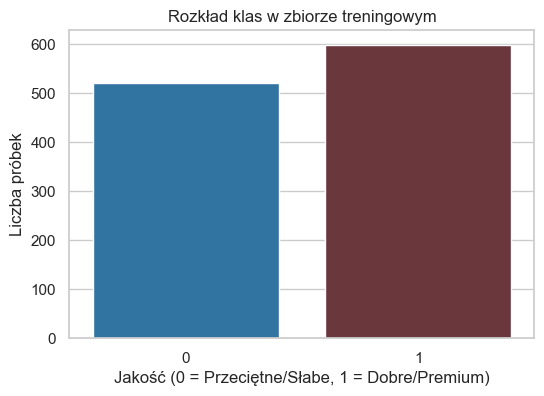

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette=['#1f77b4', '#722F37'])
plt.title('Rozkład klas w zbiorze treningowym')
plt.xlabel('Jakość (0 = Przeciętne/Słabe, 1 = Dobre/Premium)')
plt.ylabel('Liczba próbek')
plt.show()

## Krok 3: Etap 1 - Preprocessing i Inżynieria Cech

W tej sekcji przeprowadzimy analizę i wybór najlepszych strategii przygotowania cech przy użyciu baseline K-NN (k=9).

In [16]:
LICZBA_SASIADOW = 9

def test_knn(X_train_df, X_val_df, y_train_s, y_val_s, label=""):
    """Szybki test baseline K-NN w celu oceny wpływu inżynierii cech."""
    knn = KNeighborsClassifier(n_neighbors=LICZBA_SASIADOW)
    knn.fit(X_train_df, y_train_s)
    acc = accuracy_score(y_val_s, knn.predict(X_val_df))
    print(f" [k-NN Accuracy: {label}] -> {acc:.4f}")
    return acc

### Etap 1a: Zarządzanie brakami danych
Porównamy trzy strategie: usuwanie wierszy z brakami, uzupełnianie medianą oraz uzupełnianie regresyjne (MICE).

In [17]:
X_train_num = X_train.select_dtypes(include=[np.number])
X_val_num = X_val.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

braki = X_train_num.isnull().sum()
print(f"Liczba braków w kolumnach:\n{braki[braki > 0] if braki.sum() > 0 else 'Brak brakujących wartości w zbiorze.'}")

# Strategia 1: Usuwanie braków
X_train_drop = X_train_num.dropna()
y_train_drop = y_train.loc[X_train_drop.index]
X_val_drop = X_val_num.dropna()
y_val_drop = y_val.loc[X_val_drop.index]

if len(X_train_drop) > 0 and len(X_val_drop) > 0:
    acc_drop = test_knn(X_train_drop, X_val_drop, y_train_drop, y_val_drop, "Po usunięciu")
else:
    acc_drop = 0.0

# Strategia 2: Imputacja medianą
imputer_med = SimpleImputer(strategy='median')
X_train_imp_med = pd.DataFrame(imputer_med.fit_transform(X_train_num), columns=X_train_num.columns, index=X_train_num.index)
X_val_imp_med = pd.DataFrame(imputer_med.transform(X_val_num), columns=X_val_num.columns, index=X_val_num.index)
acc_imp_med = test_knn(X_train_imp_med, X_val_imp_med, y_train, y_val, "Po medianie")

# Strategia 3: Imputacja regresyjna (IterativeImputer MICE)
imputer_reg = IterativeImputer(random_state=42, max_iter=10)
X_train_imp_reg = pd.DataFrame(imputer_reg.fit_transform(X_train_num), columns=X_train_num.columns, index=X_train_num.index)
X_val_imp_reg = pd.DataFrame(imputer_reg.transform(X_val_num), columns=X_val_num.columns, index=X_val_num.index)
acc_imp_reg = test_knn(X_train_imp_reg, X_val_imp_reg, y_train, y_val, "Po regresji")

# Wybór najlepszej metody
wyniki_imputacji = {
    "Usunięcie braków": (acc_drop, "drop"),
    "Imputacja medianą": (acc_imp_med, "median"),
    "Imputacja regresyjna": (acc_imp_reg, "regression")
}
najlepsza_metoda = max(wyniki_imputacji, key=lambda k: wyniki_imputacji[k][0])
val_acc = wyniki_imputacji[najlepsza_metoda][0]
typ_imputacji = wyniki_imputacji[najlepsza_metoda][1]

if typ_imputacji == "drop":
    X_train_final, y_train_final = X_train_drop, y_train_drop
    X_val_final, y_val_final = X_val_drop, y_val_drop
    X_test_final = X_test_num.dropna()
    y_test_final = y_test.loc[X_test_final.index]
elif typ_imputacji == "median":
    X_train_final, y_train_final = X_train_imp_med, y_train
    X_val_final, y_val_final = X_val_imp_med, y_val
    X_test_final = pd.DataFrame(imputer_med.transform(X_test_num), columns=X_test_num.columns, index=X_test_num.index)
    y_test_final = y_test
else:
    X_train_final, y_train_final = X_train_imp_reg, y_train
    X_val_final, y_val_final = X_val_imp_reg, y_val
    X_test_final = pd.DataFrame(imputer_reg.transform(X_test_num), columns=X_test_num.columns, index=X_test_num.index)
    y_test_final = y_test

print(f"\nZatwierdzono metodę imputacji: {najlepsza_metoda} | Baseline Accuracy: {val_acc:.4f}")

Liczba braków w kolumnach:
Brak brakujących wartości w zbiorze.
 [k-NN Accuracy: Po usunięciu] -> 0.6417
 [k-NN Accuracy: Po medianie] -> 0.6417
 [k-NN Accuracy: Po regresji] -> 0.6417

Zatwierdzono metodę imputacji: Usunięcie braków | Baseline Accuracy: 0.6417


### Etap 1b: Analiza skośności i logarytmowanie
Cechy, których skośność przekracza próg 0.75, zostaną przekształcone funkcją `log1p`.

In [18]:
skew_threshold = 0.75
skew_vals = X_train_final.skew()
skewed_features = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()
print(f"Cechy wytypowane do transformacji logarytmicznej: {skewed_features}")

X_train_trans = X_train_final.copy()
X_val_trans = X_val_final.copy()
X_test_trans = X_test_final.copy()

for col in skewed_features:
    X_train_trans[col] = np.log1p(np.clip(X_train_trans[col], 0, None))
    X_val_trans[col] = np.log1p(np.clip(X_val_trans[col], 0, None))
    X_test_trans[col] = np.log1p(np.clip(X_test_trans[col], 0, None))

acc_trans = test_knn(X_train_trans, X_val_trans, y_train_final, y_val_final, "Po transformacji log1p")

if acc_trans > val_acc:
    X_train_final, X_val_final, X_test_final = X_train_trans, X_val_trans, X_test_trans
    print(f"Zatwierdzono transformację logarytmiczną (Poprawa z {val_acc:.4f} na {acc_trans:.4f})")
    val_acc = acc_trans
else:
    print("Odrzucono transformację logarytmiczną (nie poprawiła wyniku).")

Cechy wytypowane do transformacji logarytmicznej: ['fixed acidity', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates', 'alcohol']
 [k-NN Accuracy: Po transformacji log1p] -> 0.7083
Zatwierdzono transformację logarytmiczną (Poprawa z 0.6417 na 0.7083)


### Etap 1c: Standaryzacja cech
Sprawdzimy, czy standaryzacja (sprowadzenie cech do średniej 0 i wariancji 1) za pomocą `StandardScaler` poprawi dokładność modelu.

In [19]:
scaler = StandardScaler()
X_train_std = pd.DataFrame(scaler.fit_transform(X_train_final), columns=X_train_final.columns, index=X_train_final.index)
X_val_std = pd.DataFrame(scaler.transform(X_val_final), columns=X_val_final.columns, index=X_val_final.index)
X_test_std = pd.DataFrame(scaler.transform(X_test_final), columns=X_test_final.columns, index=X_test_final.index)

acc_std = test_knn(X_train_std, X_val_std, y_train_final, y_val_final, "Po standaryzacji")

if acc_std > val_acc:
    X_train_final, X_val_final, X_test_final = X_train_std, X_val_std, X_test_std
    print(f"Zatwierdzono standaryzację (Poprawa z {val_acc:.4f} na {acc_std:.4f})")
    val_acc = acc_std
else:
    print("Odrzucono standaryzację.")

 [k-NN Accuracy: Po standaryzacji] -> 0.7542
Zatwierdzono standaryzację (Poprawa z 0.7083 na 0.7542)


### Etap 1d: Redukcja współliniowości (VIF)
Wielokollinearność cech obniża stabilność modeli liniowych i utrudnia interpretację. Usuniemy cechy posiadające wskaźnik VIF powyżej progu 10.

In [20]:
def compute_vif(df_vif):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(len(df_vif.columns))]
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

X_train_vif = X_train_final.copy()
X_val_vif = X_val_final.copy()
X_test_vif = X_test_final.copy()
removed_vif = []
iteration = 1
vif_threshold = 10.0

while True:
    try:
        vif_df = compute_vif(X_train_vif)
        max_vif = vif_df.iloc[0]["VIF"]
        col_to_remove = vif_df.iloc[0]["feature"]

        if max_vif > vif_threshold:
            print(f" Iteracja {iteration}: Usuwam cechę '{col_to_remove}' (VIF = {max_vif:.2f})")
            removed_vif.append(col_to_remove)
            X_train_vif = X_train_vif.drop(columns=[col_to_remove])
            X_val_vif = X_val_vif.drop(columns=[col_to_remove])
            X_test_vif = X_test_vif.drop(columns=[col_to_remove])
            iteration += 1
        else:
            print(f" Wszystkie cechy mają VIF <= {vif_threshold}.")
            break
    except Exception as e:
        print(f" Błąd podczas VIF: {e}")
        break

if len(removed_vif) > 0:
    acc_vif = test_knn(X_train_vif, X_val_vif, y_train_final, y_val_final, "Po redukcji VIF")
    if acc_vif >= val_acc:
        X_train_final, X_val_final, X_test_final = X_train_vif, X_val_vif, X_test_vif
        print(f"Zatwierdzono redukcję VIF (Wynik: {acc_vif:.4f}, Usunięto: {removed_vif})")
        val_acc = acc_vif
    else:
        print(f"Odrzucono redukcję VIF (Spadek dokładności do {acc_vif:.4f}).")
else:
    print("Brak współliniowych cech do usunięcia.")

 Wszystkie cechy mają VIF <= 10.0.
Brak współliniowych cech do usunięcia.


### Etap 1e: Detekcja obserwacji wpływowych (Odległość Cooka)
Wpływowe obserwacje (outliery) potrafią zniekształcić wyniki uczenia. Użyjemy odległości Cooka (Cook's Distance) z logitowego modelu statystycznego do ich eliminacji.

In [21]:
try:
    X_train_const = sm.add_constant(X_train_final)
    logit_model = sm.Logit(y_train_final.values, X_train_const).fit(disp=0)
    influence = logit_model.get_influence()
    cooks_d = influence.cooks_distance[0]
    
    cook_threshold = 4.0 / len(X_train_final)
    safe_indices = np.where(cooks_d <= cook_threshold)[0]
    n_influential = len(cooks_d) - len(safe_indices)
    
    print(f"Liczba punktów wpływowych (Cook > {cook_threshold:.5f}): {n_influential} ({n_influential/len(X_train_final):.1%})")
    
    if n_influential > 0:
        X_train_clean = X_train_final.iloc[safe_indices]
        y_train_clean = y_train_final.iloc[safe_indices]
        
        acc_clean = test_knn(X_train_clean, X_val_final, y_train_clean, y_val_final, "Po usunięciu Cooka")
        
        if acc_clean >= val_acc:
            X_train_final = X_train_clean
            y_train_final = y_train_clean
            print(f"Zatwierdzono filtrację odległości Cooka | Nowe Baseline Accuracy: {acc_clean:.4f}")
            val_acc = acc_clean
        else:
            print(f"Odrzucono filtrację Cooka (Spadek dokładności do {acc_clean:.4f})")
except Exception as e:
    print(f"Pominięto odległość Cooka: {e}")

Liczba punktów wpływowych (Cook > 0.00357): 67 (6.0%)
 [k-NN Accuracy: Po usunięciu Cooka] -> 0.7583
Zatwierdzono filtrację odległości Cooka | Nowe Baseline Accuracy: 0.7583


## Krok 4: Etap 2 - Optymalizacja i dobór modelu

W tej sekcji połączymy zbiory treningowy i walidacyjny w jeden zbiór, na którym przeprowadzimy 5-krotną walidację krzyżową (StratifiedKFold) dla różnych modeli klasyfikacyjnych, a następnie dostroimy hiperparametry najlepszego modelu.

In [ ]:
# Połączenie zbiorów treningowego i walidacyjnego (dla 5-krotnej walidacji krzyżowej)
X_train_cv = pd.concat([X_train, X_val], axis=0)
y_train_cv = pd.concat([y_train, y_val], axis=0)

print(f"Rozmiar połączonego zbioru do Walidacji Krzyżowej: {len(X_train_cv)} próbek.")
numeric_features = X_train_cv.select_dtypes(include=[np.number]).columns.tolist()

# Preprocesor oparty na Etapie 1 (MICE -> log1p -> StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', IterativeImputer(random_state=42, max_iter=10)),
    ('log_transform', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Zbiór algorytmów klasyfikacyjnych
models = {
    "Naiwny Bayes": GaussianNB(),
    "Drzewo Decyzyjne": DecisionTreeClassifier(random_state=42),
    "Regresja Logistyczna": LogisticRegression(max_iter=1000, random_state=42),
    "K-NN (k=9)": KNeighborsClassifier(n_neighbors=9),
    "SVM (RBF)": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Las Losowy": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

print(f"\n{'Model':<25} | {'Średni Acc (CV)':<16} | {'Odchylenie +/-'}")
print("-" * 65)

cv_results = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    scores = cross_val_score(pipe, X_train_cv, y_train_cv, cv=kf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores.mean()
    print(f"{name:<25} | {scores.mean():<16.4f} | {scores.std():.4f}")

best_model_name = max(cv_results, key=cv_results.get)
print(f"\n Zwycięzca Walidacji Krzyżowej: {best_model_name} (Średnia dokładność: {cv_results[best_model_name]:.4f})")

Rozmiar połączonego zbioru do Walidacji Krzyżowej: 1359 próbek.

Model                     | Średni Acc (CV)  | Odchylenie +/-
-----------------------------------------------------------------
Naiwny Bayes              | 0.7219           | 0.0271
Drzewo Decyzyjne          | 0.7277           | 0.0146
Regresja Logistyczna      | 0.7476           | 0.0178
K-NN (k=9)                | 0.7211           | 0.0284
SVM (RBF)                 | 0.7675           | 0.0189
Gradient Boosting         | 0.7741           | 0.0284
Las Losowy                | 0.8065           | 0.0230

🏆 Zwycięzca Walidacji Krzyżowej: Las Losowy (Średnia dokładność: 0.8065)


### Strojenie hiperparametrów dla modelu Lasu Losowego

In [ ]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Strojenie modeli za pomocą GridSearchCV...")
grid_search.fit(X_train_cv, y_train_cv)

print(f"\nNajlepsze parametry: {grid_search.best_params_}")
print(f"Najlepszy wynik dokładności (CV): {grid_search.best_score_:.4f}")

baseline_diff = grid_search.best_score_ - cv_results[best_model_name]
if baseline_diff > 0:
    print(f" Poprawa dokładności dzięki dostrojeniu: +{baseline_diff:.4f} (+{baseline_diff*100:.2f}%)")
else:
    print("Model z domyślnymi parametrami okazał się optymalny.")

Strojenie modeli za pomocą GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Najlepsze parametry: {'classifier__max_depth': 15, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Najlepszy wynik dokładności (CV): 0.8146
📈 Poprawa dokładności dzięki dostrojeniu: +0.0081 (+0.81%)


## Krok 5: Etap 3 - Ewaluacja i Wykresy

Wytrenujemy ostateczny optymalny potok (Pipeline) z nastrojonymi parametrami na zbiorze treningowym (z którego wykluczono punkty wpływowe) i ocenimy go na całkowicie izolowanym zbiorze testowym. Następnie narysujemy ostateczne wykresy.

In [24]:
# Budowa ostatecznego potoku z nastrojonymi parametrami
best_rf = RandomForestClassifier(
    n_estimators=grid_search.best_params_['classifier__n_estimators'],
    max_depth=grid_search.best_params_['classifier__max_depth'],
    min_samples_split=grid_search.best_params_['classifier__min_samples_split'],
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_rf)
])

# Filtracja odległości Cooka na pełnym połączonym zbiorze treningowym (Train + Val)
try:
    X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_train_val = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
    
    X_train_val_prep = preprocessor.fit_transform(X_train_val)
    X_train_val_prep = pd.DataFrame(X_train_val_prep, columns=numeric_features)
    X_train_val_const = sm.add_constant(X_train_val_prep)
    
    logit_model = sm.Logit(y_train_val.values, X_train_val_const).fit(disp=0)
    cooks_d = logit_model.get_influence().cooks_distance[0]
    
    cook_threshold = 4.0 / len(X_train_val)
    safe_indices = np.where(cooks_d <= cook_threshold)[0]
    X_train_clean = X_train_val.iloc[safe_indices]
    y_train_clean = y_train_val.iloc[safe_indices]
    print(f"Odległość Cooka: Usunięto {len(cooks_d) - len(safe_indices)} wpływowych obserwacji z pełnego zbioru treningowego.")
except Exception as e:
    print(f"Błąd przy odległości Cooka (stosowanie pełnego zbioru): {e}")
    X_train_clean = X_train_val
    y_train_clean = y_train_val

# Trening ostatecznego potoku
print("Trening ostatecznego potoku na czystych danych...")
final_pipeline.fit(X_train_clean, y_train_clean)

# Ewaluacja na zbiorze testowym
y_pred_test = final_pipeline.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)
print(f"\n OSTATECZNA DOKŁADNOŚĆ NA ZBIORZE TESTOWYM: {test_acc:.4f}")

print("\nRAPORT KLASYFIKACJI:")
print(classification_report(y_test, y_pred_test, target_names=["Przeciętne/Słabe (0)", "Dobre/Premium (1)"]))

Odległość Cooka: Usunięto 77 wpływowych obserwacji z pełnego zbioru treningowego.
Trening ostatecznego potoku na czystych danych...

 OSTATECZNA DOKŁADNOŚĆ NA ZBIORZE TESTOWYM: 0.7542

RAPORT KLASYFIKACJI:
                      precision    recall  f1-score   support

Przeciętne/Słabe (0)       0.73      0.75      0.74       112
   Dobre/Premium (1)       0.78      0.76      0.77       128

            accuracy                           0.75       240
           macro avg       0.75      0.75      0.75       240
        weighted avg       0.75      0.75      0.75       240



### Generowanie wykresów

In [ ]:
# 1. Macierz pomyłek
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Przeciętne/Słabe (0)", "Dobre/Premium (1)"])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Macierz Pomyłek - Zbiór Testowy')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Krzywa ROC
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#722F37', lw=2, label=f'Krzywa ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#A0A0A0', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('Krzywa ROC - Zbiór Testowy')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Krzywe uczenia
train_sizes, train_scores, val_scores = learning_curve(
    estimator=final_pipeline,
    X=X_train_clean,
    y=y_train_clean,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#722F37', label='Dokładność treningowa')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#722F37')
plt.plot(train_sizes, val_mean, 's-', color='#1f77b4', label='Dokładność walidacyjna (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#1f77b4')
plt.xlabel('Rozmiar zbioru treningowego')
plt.ylabel('Dokładność (Accuracy)')
plt.title('Krzywe Uczenia - Las Losowy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## Krok 6: Etap 4 - Selekcja Cech, Model Lekki i Eksport

Wytrenujemy model na pełnym zbiorze danych, aby wyznaczyć ostateczną ważność cech i wyeksportować lekki model (Lightweight RF) bazujący na 5 najważniejszych cechach.

In [ ]:
# Połączenie wszystkich zbiorów danych
X_full = pd.concat([X_train, X_val, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val, y_test], axis=0).reset_index(drop=True)

# Trenowanie pełnego potoku na pełnych danych
print("Trening potoku na pełnym zbiorze danych...")
final_pipeline.fit(X_full, y_full)

# Odczyt ważności cech
importances = final_pipeline.named_steps['classifier'].feature_importances_
fi_df = pd.DataFrame({
    'Cecha': numeric_features,
    'Znaczenie': importances
}).sort_values(by='Znaczenie', ascending=False)

print("\n--- TOP 5 NAJWAŻNIEJSZYCH CECH ---")
print(fi_df.head(5).to_string(index=False))

Wizualizujemy ważność wszystkich cech.

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Znaczenie', y='Cecha', data=fi_df, palette='viridis')
plt.title('Istotność cech w modelu Lasu Losowego')
plt.xlabel('Względna istotność cech')
plt.ylabel('Nazwa cechy')
plt.show()

Budujemy lekki model (Lightweight RF) wytrenowany wyłącznie na 5 najistotniejszych cechach bazowych.

In [ ]:
top_5_features = fi_df['Cecha'].head(5).tolist()
print(f"Wybrane cechy bazowe do modelu lekkiego: {top_5_features}")

X_light = X_full[top_5_features]

light_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(
        n_estimators=grid_search.best_params_['classifier__n_estimators'],
        max_depth=grid_search.best_params_['classifier__max_depth'],
        min_samples_split=grid_search.best_params_['classifier__min_samples_split'],
        random_state=42,
        n_jobs=-1
    ))
])

print("\nTrenowanie lekkiego modelu na wyselekcjonowanych cechach...")
light_pipeline.fit(X_light, y_full)

# Eksport lekkiego modelu do pliku .pkl
model_path = 'wine_model_light.pkl'
joblib.dump((light_pipeline, top_5_features), model_path)
print(f"\nLekki model wyeksportowany pomyślnie do pliku: {os.path.abspath(model_path)}")